# Quick-look for KUL-TN-20 simulations

This notebook can be used to have a quicklook at the that product for the simulations described in PLATO-PL-TN-0020. Note that the `LightCurve` class used to analyse the data assumes a identical structure of the data products as they are delivered on the KU Leuven FTP server.

### Setup notebook

In [53]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [54]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [79]:
# Load all data for a single star
idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002"
# idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1_corrected/000000012"
phot = LightCurve(idir, mode="multi")

# To fetch a specific light curve, use instead:
# lc = LightCurve(f"{idir}/000000083/000000083_Ncam1.1_Q23.ftr")

In [80]:
# Unzip all compressed files for the same star
phot.unpack()

In [123]:
# Fetch all feather filenames
filenames = phot.files("ftr")
filename  = filenames[0]
filenames

array(['/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002/000000002_Ncam1.1_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002/000000002_Ncam1.2_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002/000000002_Ncam1.3_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002/000000002_Ncam1.4_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002/000000002_Ncam1.5_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002/000000002_Ncam1.6_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002/000000002_Ncam2.1_Q23.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002/000000002_Ncam2.1_Q24.ftr',
       '/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P5/000000002/000000002_Ncam2.2_Q23.ftr',
       '/STER/platodata/PLATOSIM/simu

In [108]:
# Fetch the first light curve for this star
lc = LightCurve(filename)
lc.data().head()

,index,time,flux,xc,yc,flux_cor
0,0,178848012.5,182637.836428,3.088525,2.770187,1.075493
1,1,178848037.5,183622.977376,3.084137,2.765554,1.075494
2,2,178848062.5,183280.787544,3.085669,2.770193,1.075492
3,3,178848087.5,182322.492369,3.085223,2.770074,1.075508
4,4,178848112.5,183887.804428,3.091934,2.764524,1.075510


In [109]:
# Get target star information
star = lc.star_info(phot.files("cat")[0])
print(f"""
Pmag : {star[0]}
rOA  : {star[1]}
rCOB : {star[2]}
nCon : {star[3]}
rCon : {star[4]}
dMag : {star[5]}
SPR  : {star[6]}
""")


Pmag : 10.83
rOA  : 8.075741083039848
rCOB : 0.4255805951292135
nCon : 4
rCon : 5.226841369716433
dMag : 1.2899999999999991
SPR  : 0.6922540384180277



In [125]:
# Get noise-less light curve
lc.varsource()

,time,spot,gran,puls,tran,sum
0,171072000.0,-424.178621,0.765052,0.404825,0.0,-423.008744
1,171072025.0,-424.192910,2.054737,1.273541,0.0,-420.864631
2,171072050.0,-424.207156,5.050976,1.702217,0.0,-417.453962
3,171072075.0,-424.221359,6.980431,2.522017,0.0,-414.718911
4,171072100.0,-424.235519,10.510768,3.340713,0.0,-410.384037
...,...,...,...,...,...,...
622075,186623875.0,-123.690085,-32.095610,-16.296435,0.0,-172.082130
622076,186623900.0,-123.644317,-28.433645,-18.878844,0.0,-170.956806
622077,186623925.0,-123.598538,-20.891573,-19.981375,0.0,-164.471487
622078,186623950.0,-123.552750,-11.230948,-19.690668,0.0,-154.474366


<IPython.core.display.Javascript object>


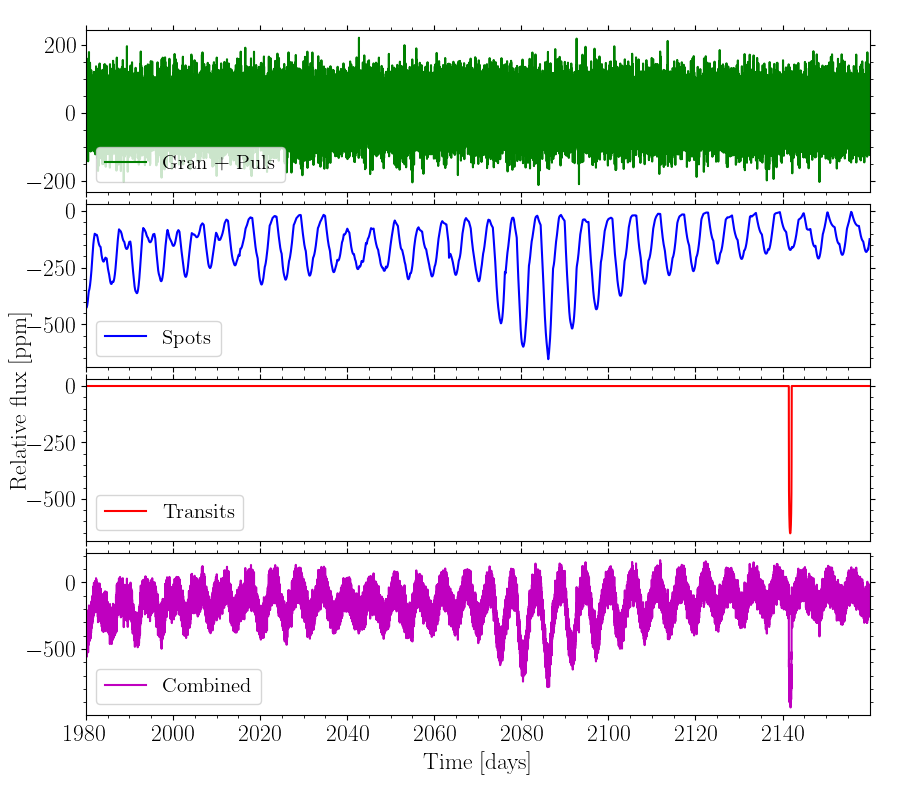

In [111]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

<IPython.core.display.Javascript object>


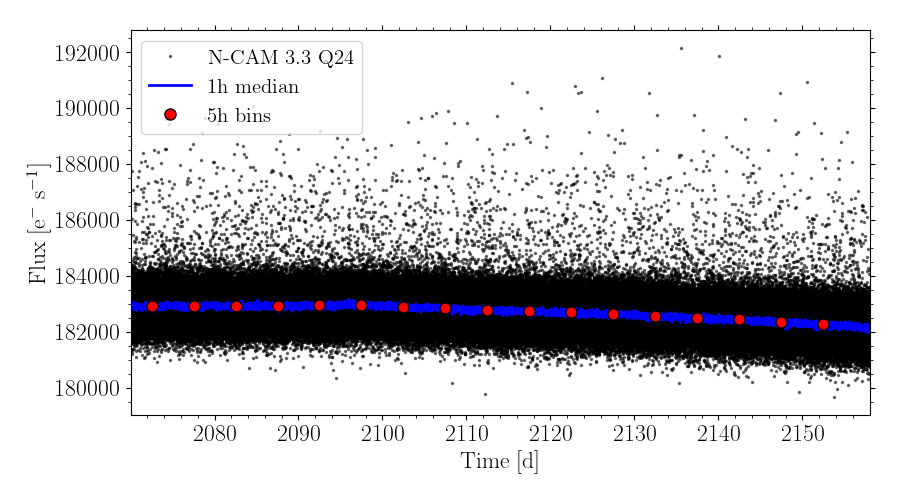

In [112]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", binsize=5, median_filter=1);

<IPython.core.display.Javascript object>


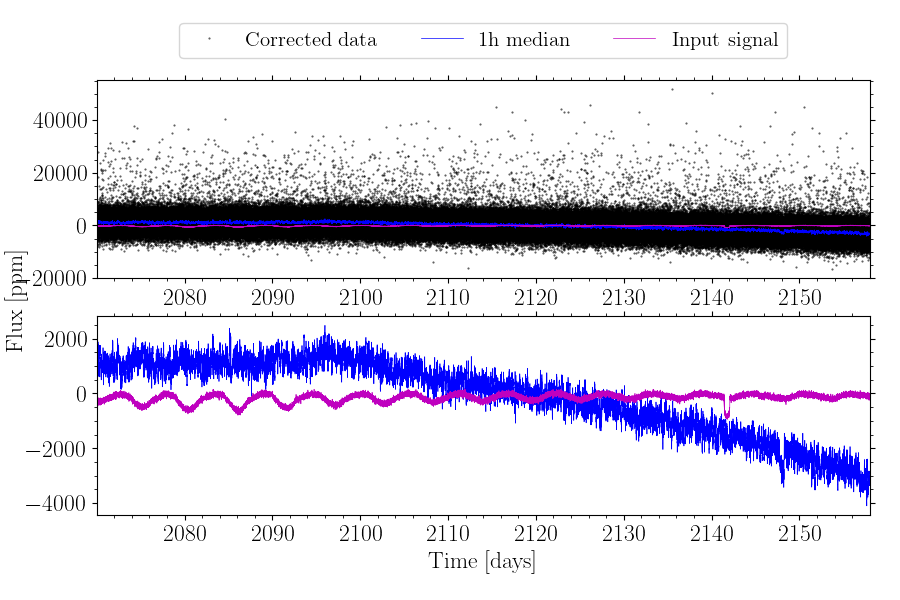

In [113]:
# Plot a quick O-C comparison plot 
fig, ax = lc.plot_oc();

<IPython.core.display.Javascript object>


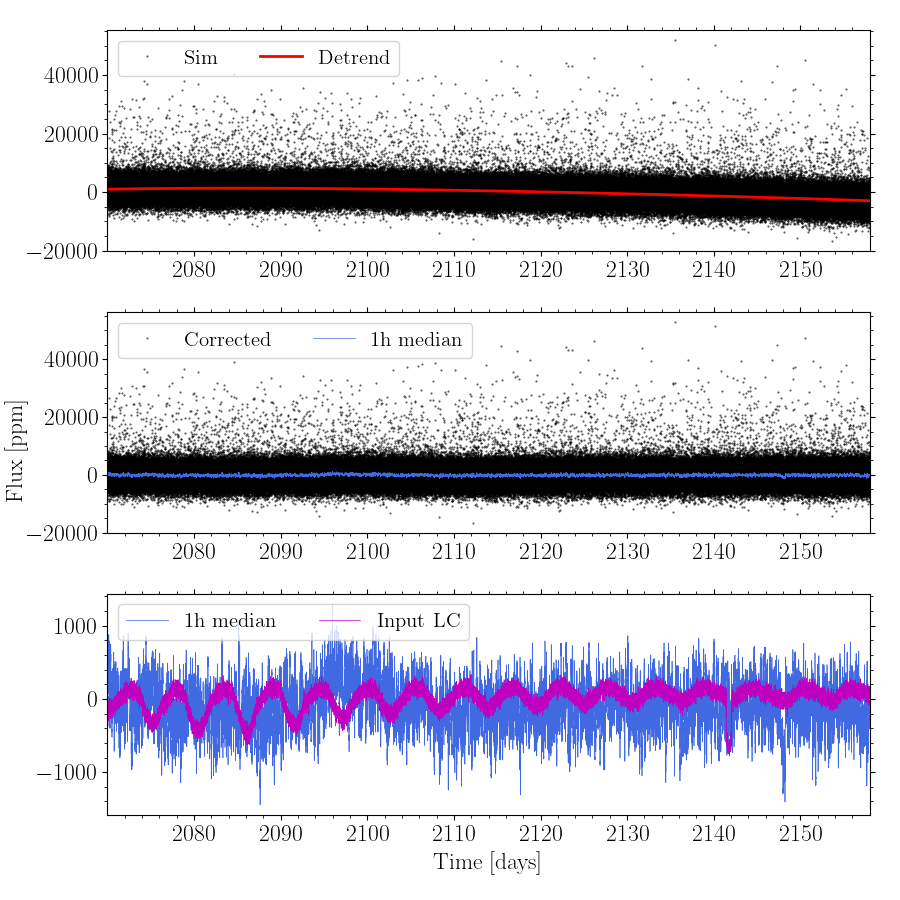

In [114]:
# Detrend light curve
lc.plot_detrend(poly_deg=4, binsize=1);

In [115]:
# Get NSR per 1h for detrended light curve 
lc.detrend(poly_deg=4)
lc.getNSR(column="flux_det", binhour=1, influx="ppm")

48.153247528002915

In [116]:
df = lc.data()
df["flux_det"].std()

586.6081597780968

In [117]:
# With the long trend systematics the NSR is somewhat larger
lc.getNSR()

263.5542953641708

In [68]:
# Remove files again to keep server clean
phot.remove()